# Part 4: Benchmarking and Evaluation

This notebook completes the project by comprehensively evaluating the two implemented deepfake detection models: **XceptionNet** and **FFD (Face Forgery Detection)**.

Aligned with the methodology presented in *"Towards Benchmarking and Evaluating Deepfake Detection"*, this notebook conducts multi-dimensional evaluation covering:
1. **Discriminative Performance** (Accuracy, F1-Score, AUC-ROC)
2. **Computational Cost** (FLOPs, Parameter Count, Inference Time)
3. **Robustness to Real-world Perturbations** (Blur, JPEG Compression, Noise, Contrast, Saturation)
4. **Attention Map Visualisation** (For FFD to demonstrate interpretability)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q timm thop opencv-python scikit-learn matplotlib pandas

In [3]:
import os
import cv2
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from thop import profile
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", DEVICE)

Using Device: cuda


## 1. Load Dataset Manifest

In [4]:
OUTPUT_PATH = "/content/drive/MyDrive/Deepfake_Project/Processed"
MODEL_SAVE_PATH = "/content/drive/MyDrive/Deepfake_Project/Models"
TEST_CSV = os.path.join(OUTPUT_PATH, "test.csv")

if os.path.exists(TEST_CSV):
    test_df = pd.read_csv(TEST_CSV)
    print("Test samples:", len(test_df))
else:
    print(f"Could not find test.csv at {TEST_CSV}")
    # Dummy dataframe for demonstration purposes if CSV is missing
    test_df = pd.DataFrame({"image": [], "label": []})

Test samples: 1682


## 2. Define Perturbations and Dataloader

In [5]:
def apply_perturbation(img, p_type):
    if p_type == "none":
        return img
    elif p_type == "blur":
        return cv2.GaussianBlur(img, (7, 7), 3)
    elif p_type == "jpeg":
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 40]
        result, encimg = cv2.imencode('.jpg', img, encode_param)
        return cv2.imdecode(encimg, 1)
    elif p_type == "noise":
        noise = np.random.normal(0, 25, img.shape).astype(np.float32)
        noisy = cv2.add(img.astype(np.float32), noise)
        return np.clip(noisy, 0, 255).astype(np.uint8)
    elif p_type == "contrast":
        return cv2.convertScaleAbs(img, alpha=2.0, beta=0)
    elif p_type == "saturation":
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 2.0, 0, 255)
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    return img

class DeepfakeTestDataset(Dataset):
    def __init__(self, df, img_size=256, perturbation="none"):
        self.df = df
        self.img_size = img_size
        self.perturbation = perturbation
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["image"])
        if img is None:
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Apply perturbation
        img = apply_perturbation(img, self.perturbation)

        img = cv2.resize(img, (self.img_size, self.img_size))
        img = self.transform(img)
        label = torch.tensor(row["label"], dtype=torch.float32)
        return img, label

## 3. Define Architectures

In [6]:
# XceptionNet Architecture
class XceptionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("xception", pretrained=False, num_classes=0, global_pool="")
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(2048, 1)
        )
    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        return self.fc(x)

# FFD Architecture
class AttentionHead(nn.Module):
    def __init__(self, in_channels, map_size):
        super().__init__()
        self.map_size = map_size
        self.attn_conv = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 1, kernel_size=1, bias=True),
            nn.Sigmoid()
        )
    def forward(self, x):
        attn = self.attn_conv(x)
        attn = F.interpolate(attn, size=(self.map_size, self.map_size), mode="bilinear", align_corners=False)
        return attn

class FFDModel(nn.Module):
    def __init__(self, map_size=19):
        super().__init__()
        self.backbone = timm.create_model("xception", pretrained=False, num_classes=0, global_pool="")
        self.attention_head = AttentionHead(2048, map_size)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(2048, 256), nn.ReLU(inplace=True), nn.Dropout(0.5), nn.Linear(256, 1))
        self.appearance_classifier = nn.Sequential(nn.Flatten(), nn.Linear(2048, 1))

    def forward(self, x):
        feat = self.backbone(x)
        attn_map = self.attention_head(feat)
        pooled = self.global_pool(feat)
        cls_logit = self.classifier(pooled)
        return cls_logit, attn_map

## 4. Evaluation and Complexity Functions

In [7]:
@torch.no_grad()
def evaluate_model(model, dataloader, device, is_ffd=False):
    model.eval()
    all_preds = []
    all_labels = []

    start_time = time.time()
    for imgs, labels in dataloader:
        imgs = imgs.to(device)
        labels = labels.numpy()

        if is_ffd:
            logits, _ = model(imgs)
        else:
            logits = model(imgs)

        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        all_preds.extend(probs)
        all_labels.extend(labels)

    total_time = time.time() - start_time
    avg_inference_time = total_time / max(1, len(all_labels))

    if len(all_labels) == 0:
        return 0, 0, 0, 0, [], []

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    preds_binary = (all_preds >= 0.5).astype(int)

    acc = accuracy_score(all_labels, preds_binary)
    f1 = f1_score(all_labels, preds_binary)
    auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5

    return acc, f1, auc, avg_inference_time, all_labels, all_preds

def get_model_complexity(model, input_size):
    device = next(model.parameters()).device
    dummy_input = torch.randn(1, 3, input_size, input_size).to(device)
    macs, params = profile(model, inputs=(dummy_input, ), verbose=False)
    return macs * 2, params  # FLOPs = 2 * MACs


## 5. Calculate Computational Cost (FLOPs & Parameters)

In [8]:
models_info = {
    "XceptionNet": {"model": XceptionClassifier().to(DEVICE), "size": 299, "is_ffd": False, "weights": "xception_best.pth"},
    "FFD": {"model": FFDModel().to(DEVICE), "size": 299, "is_ffd": True, "weights": "ffd_best.pth"}
}

print("Model Complexity:")
print("-" * 50)
for name, info in models_info.items():
    flops, params = get_model_complexity(info["model"], info["size"])
    print(f"{name}:")
    print(f"  Parameters: {params:,}")
    print(f"  FLOPs: {flops / 1e9:.4f} G\n")

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Model Complexity:
--------------------------------------------------
XceptionNet:
  Parameters: 20,809,001.0
  FLOPs: 16.8802 G

FFD:
  Parameters: 21,594,282.0
  FLOPs: 16.9338 G



## 6. Run Robustness Benchmarking

In [9]:
perturbations = ["none", "blur", "jpeg", "noise", "contrast", "saturation"]

results = {name: {} for name in models_info.keys()}
roc_data = {name: {} for name in models_info.keys()}

batch_size = 16

if len(test_df) > 0:
    # Load pretrained weights here if available, e.g.:
    # for info in models_info.values():
    #     info["model"].load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, info["weights"])), strict=False)

    for p in perturbations:
        print(f"\nEvaluating Perturbation: {p.upper()}")
        print("-" * 50)
        for name, info in models_info.items():
            dataset = DeepfakeTestDataset(test_df, img_size=info["size"], perturbation=p)
            loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

            acc, f1, auc, inf_time, labels, preds = evaluate_model(info["model"], loader, DEVICE, info["is_ffd"])
            results[name][p] = {"AUC": auc, "Acc": acc, "F1": f1, "InfTime": inf_time}
            if p == "none":
                roc_data[name] = {"labels": labels, "preds": preds}

            print(f"  {name} -> AUC: {auc:.4f} | Acc: {acc:.4f} | Inf Time/img: {inf_time:.4f}s")
else:
    print("Test dataset empty. Please verify paths.")


Evaluating Perturbation: NONE
--------------------------------------------------
  XceptionNet -> AUC: 0.4717 | Acc: 0.5000 | Inf Time/img: 0.3043s
  FFD -> AUC: 0.5239 | Acc: 0.5000 | Inf Time/img: 0.0095s

Evaluating Perturbation: BLUR
--------------------------------------------------
  XceptionNet -> AUC: 0.4712 | Acc: 0.5000 | Inf Time/img: 0.0100s
  FFD -> AUC: 0.5249 | Acc: 0.5000 | Inf Time/img: 0.0099s

Evaluating Perturbation: JPEG
--------------------------------------------------
  XceptionNet -> AUC: 0.4723 | Acc: 0.5000 | Inf Time/img: 0.0097s
  FFD -> AUC: 0.5253 | Acc: 0.5000 | Inf Time/img: 0.0098s

Evaluating Perturbation: NOISE
--------------------------------------------------
  XceptionNet -> AUC: 0.4745 | Acc: 0.5000 | Inf Time/img: 0.0167s
  FFD -> AUC: 0.5312 | Acc: 0.5000 | Inf Time/img: 0.0168s

Evaluating Perturbation: CONTRAST
--------------------------------------------------
  XceptionNet -> AUC: 0.5155 | Acc: 0.5000 | Inf Time/img: 0.0095s
  FFD -> AUC: 

## 7. Visualise Performance (ROC & Robustness)

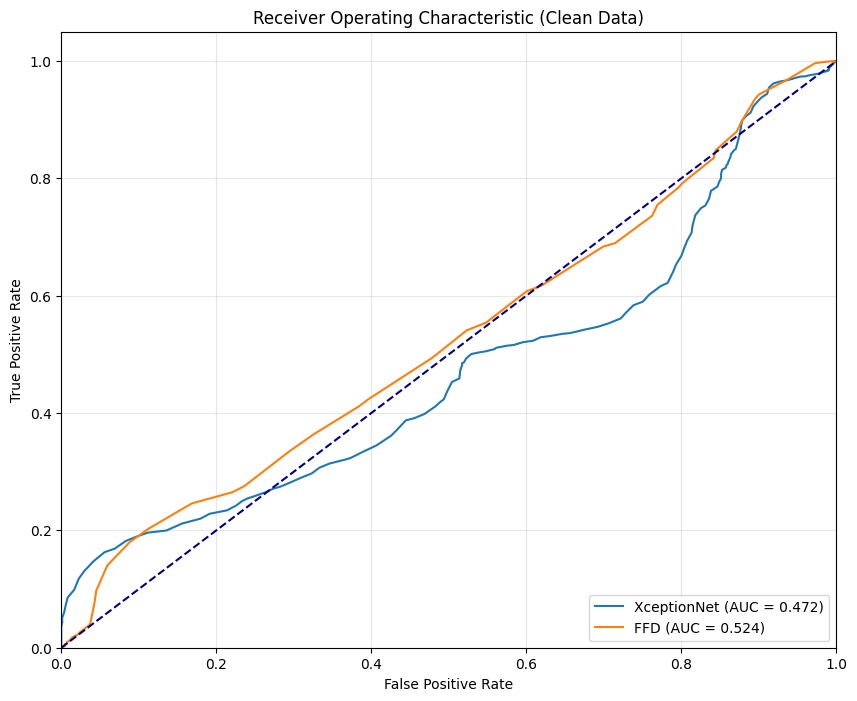

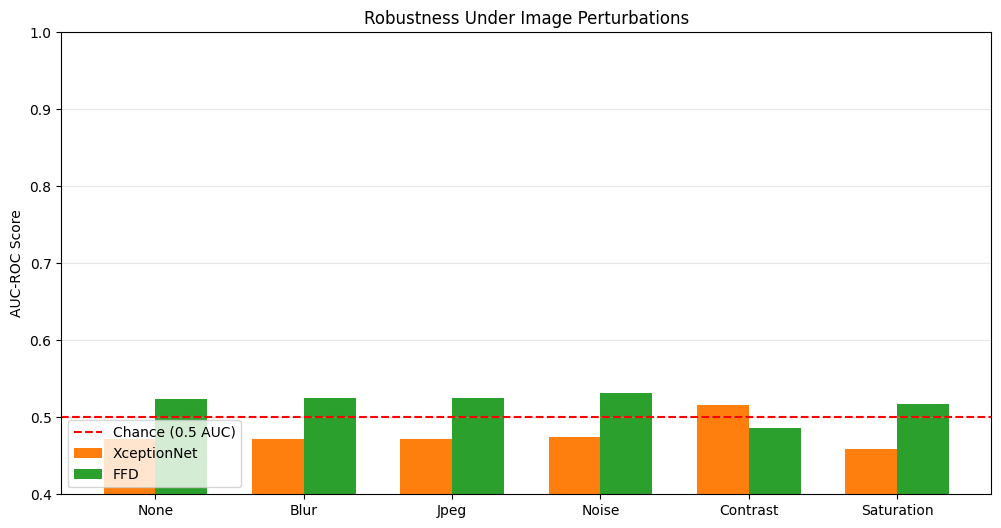

Plots saved successfully in: /content/drive/MyDrive/Deepfake_Project/Results


In [10]:
import os

# Save directory
PLOT_SAVE_PATH = "/content/drive/MyDrive/Deepfake_Project/Results"
os.makedirs(PLOT_SAVE_PATH, exist_ok=True)

if len(test_df) > 0:

    # ============================
    # 1. ROC Curve (Clean Data)
    # ============================
    plt.figure(figsize=(10, 8))

    for name, data in roc_data.items():
        fpr, tpr, _ = roc_curve(data["labels"], data["preds"])
        auc_score = results[name]["none"]["AUC"]
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (Clean Data)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # Save ROC Curve
    plt.savefig(
        os.path.join(PLOT_SAVE_PATH, "ROC_Curve_Clean_Data.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    # ============================
    # 2. Perturbation Bar Chart
    # ============================
    plt.figure(figsize=(12, 6))

    x = np.arange(len(perturbations))
    width = 0.35

    xcep_aucs = [results["XceptionNet"][p]["AUC"] for p in perturbations]
    ffd_aucs = [results["FFD"][p]["AUC"] for p in perturbations]

    plt.bar(x - width/2, xcep_aucs, width,
            label='XceptionNet', color='#ff7f0e')

    plt.bar(x + width/2, ffd_aucs, width,
            label='FFD', color='#2ca02c')

    plt.axhline(y=0.5, color='r', linestyle='--',
                label='Chance (0.5 AUC)')

    plt.ylabel('AUC-ROC Score')
    plt.title('Robustness Under Image Perturbations')
    plt.xticks(x, [p.capitalize() for p in perturbations])
    plt.legend(loc='lower left')
    plt.ylim(0.4, 1.0)
    plt.grid(axis='y', alpha=0.3)

    # Save Bar Chart
    plt.savefig(
        os.path.join(PLOT_SAVE_PATH, "Perturbation_Robustness_BarChart.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"Plots saved successfully in: {PLOT_SAVE_PATH}")

## 8. Interpretability: FFD Attention Map Visualisation

Attention Map Visualization (Real Image):


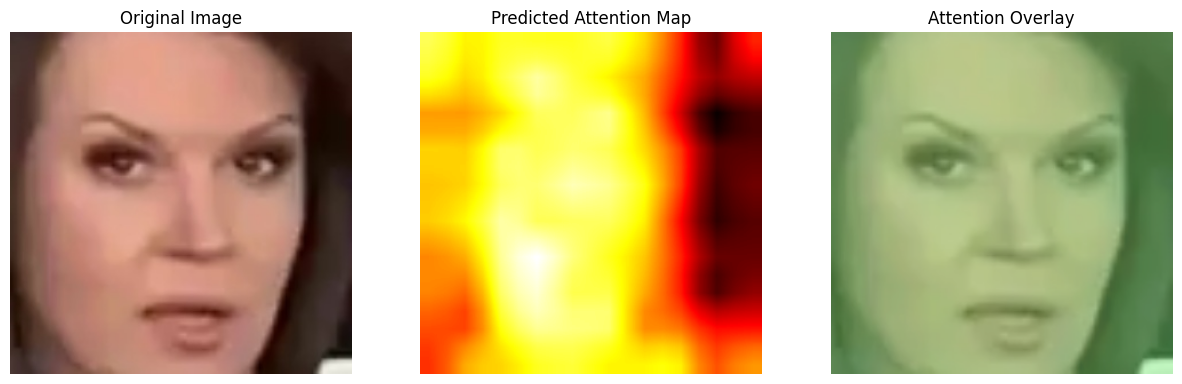

Attention Map Visualization (Fake Image):


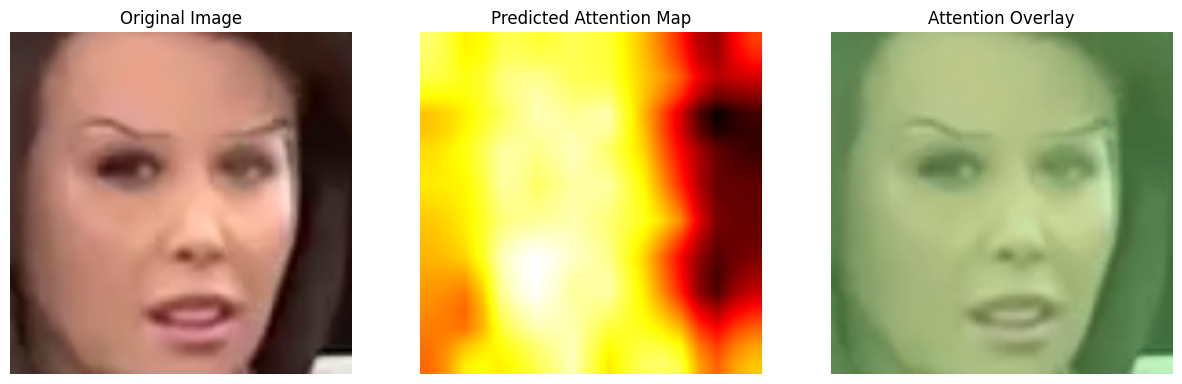

In [11]:
def visualize_ffd_attention(model, img_path, device):
    model.eval()
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not load {img_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (299, 299))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    input_tensor = transform(img_resized).unsqueeze(0).to(device)

    with torch.no_grad():
        _, attn_map = model(input_tensor)

    attn_map = attn_map.squeeze().cpu().numpy()

    # Resize attention map to image size
    attn_resized = cv2.resize(attn_map, (299, 299))

    # Create heatmap overlay
    heatmap = cv2.applyColorMap(np.uint8(255 * attn_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img_resized, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_resized)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(attn_resized, cmap='hot')
    plt.title("Predicted Attention Map")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Attention Overlay")
    plt.axis("off")

    plt.show()

if len(test_df) > 0:
    try:
        print("Attention Map Visualization (Real Image):")
        real_sample = test_df[test_df['label'] == 0].iloc[0]['image']
        visualize_ffd_attention(models_info["FFD"]["model"], real_sample, DEVICE)

        print("Attention Map Visualization (Fake Image):")
        fake_sample = test_df[test_df['label'] == 1].iloc[0]['image']
        visualize_ffd_attention(models_info["FFD"]["model"], fake_sample, DEVICE)
    except IndexError:
        print("Not enough samples to visualize.")